In [1]:
# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# make matplotlib render svg
%config InlineBackend.figure_format = 'svg'

import torch
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.utils import load_full_config
from src.mgf_dataset import create_mgf_dataset
from src.mgf_dataset import simulate_ou_process
from src.model import SimpleTransformer

# Compute likelihood of test theta values based on training distribution
from scipy.stats import lognorm


# Load experiment results

In [2]:
cfg = load_full_config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load data
data_path = os.path.join('..', cfg['paths']['mgf_data_path'])
data = torch.load(data_path, weights_only=False)


In [3]:
# Create two models: one trained, one untrained for comparison
trained_model = SimpleTransformer(**cfg['architecture'])
untrained_model = SimpleTransformer(**cfg['architecture'])

model_path = os.path.join('..', cfg['paths']['save_dir'], 'model_mgf.pth')

if os.path.exists(model_path):
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    
    # New format with loss history
    trained_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded trained model from {model_path}")
    if 'loss_history' in checkpoint:
        loss_history = checkpoint['loss_history']
        print(f"Loss history available: {len(loss_history['train_losses'])} epochs")
    if 'config' in checkpoint:
        print(f"Model trained with config: {checkpoint['config']}")

    
    trained_model.to(device)
    trained_model.eval()
    
    # Keep untrained model in eval mode for consistent comparison
    untrained_model.to(device)
    untrained_model.eval()
    
    print("Both trained and untrained models are ready for comparison")
else:
    print(f"Model not found at {model_path}")
    print("Run: python ../scripts/train.py")

Loaded trained model from ../experiments/model_mgf.pth
Model trained with config: {'physics': {'theta': 0.15, 'mu': 0.0, 'sigma': 0.2, 'dt': 0.1, 'marginal_variance': 0.2}, 'theta_sampling': {'distribution': 'lognormal', 'mean': 0.0, 'sigma': 0.4}, 'structure': {'num_trajectories': 1000, 'sequence_length': 500}, 'target': {'order': 3}, 'training': {'train_split': 0.8, 'batch_size': 64}, 'paths': {'mgf_data_path': 'data/ou_mgf.pt', 'save_dir': 'experiments', 'mgf_model_name': 'model_mgf.pth'}, 'architecture': {'d_input': 1, 'd_model': 20, 'n_head': 1, 'n_layers': 2, 'max_len': 5000, 'dim_feedforward': 64, 'd_output': 3}, 'hyperparameters': {'batch_size': 64, 'learning_rate': 0.001, 'epochs': 200}, 'system': {'device': 'cpu'}}
Both trained and untrained models are ready for comparison


In [4]:
trained_model

SimpleTransformer(
  (hermite): HermiteEmbedding()
  (input_projection): Linear(in_features=20, out_features=20, bias=True)
  (pos_encoder): PositionalEncoding()
  (layers): ModuleList(
    (0-1): 2 x AttentionBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=20, out_features=20, bias=True)
      )
      (norm1): LayerNorm((20,), eps=1e-05, elementwise_affine=True)
    )
  )
  (feedforward): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=20, bias=True)
  )
  (norm_final): LayerNorm((20,), eps=1e-05, elementwise_affine=True)
  (output_projection): Linear(in_features=20, out_features=3, bias=True)
)

# Plot loss

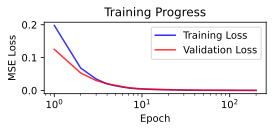

Final training loss: 0.000195
Final validation loss: 0.000274


In [5]:
# Load and plot loss history if available
loss_history_path = os.path.join('..', cfg['paths']['save_dir'], 'loss_history.pt')

if os.path.exists(loss_history_path):
    loss_data = torch.load(loss_history_path, weights_only=False)
    
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(1, 1, figsize=(4, 2))
    
    epochs = range(1, len(loss_data['train_losses']) + 1)
    ax.plot(epochs, loss_data['train_losses'], 'b-', label='Training Loss', alpha=0.8)
    
    if loss_data['val_losses']:
        ax.semilogx(epochs, loss_data['val_losses'], 'r-', label='Validation Loss', alpha=0.8)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Training Progress')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Final training loss: {loss_data['train_losses'][-1]:.6f}")
    if loss_data['val_losses']:
        print(f"Final validation loss: {loss_data['val_losses'][-1]:.6f}")
else:
    print("No loss history found. Train the model to generate loss tracking data.")

# Prediction error

In [6]:
# Generate test dataset with fixed marginal variance and varying theta
import numpy as np

# Test dataset parameters
num_test_trajectories = 5000  # Number of trajectories per theta value
num_theta_values = 100  # Number of different theta values to test
sequence_length = 25
mu = 0.0
dt = 0.1
fixed_marginal_variance = np.sqrt(0.2)  # Fixed across all trajectories

# Create equally spaced theta values in a reasonable range
theta_min = 0.1
theta_max = 5.0
theta_grid = np.linspace(theta_min, theta_max, num_theta_values)

# Repeat each theta value for num_test_trajectories times
theta_values = np.repeat(theta_grid, num_test_trajectories)
theta_tensor = torch.from_numpy(theta_values).float()

# Total number of trajectories
total_trajectories = num_theta_values * num_test_trajectories
print(f"Generating {total_trajectories} trajectories ({num_test_trajectories} per theta value)")
print(f"Theta range: {theta_min:.2f} to {theta_max:.2f} with {num_theta_values} values")

# Create D_tensor to maintain fixed marginal variance: D = marginal_variance * θ
D_tensor = fixed_marginal_variance * theta_tensor

# Generate trajectories
test_trajectories = simulate_ou_process(total_trajectories, sequence_length, theta_tensor, mu, D_tensor, dt)

# Generate corresponding targets (same structure as training data)
order = cfg['target']['order']
test_targets = torch.zeros(total_trajectories, sequence_length, order)

# Compute theoretical targets
theta_expanded = theta_tensor.unsqueeze(1)  # (total_trajectories, 1)
D_expanded = D_tensor.unsqueeze(1)  # (total_trajectories, 1)
exp_theta_dt = torch.exp(-theta_expanded * dt)

# First entry: conditional mean μ + (X_t - μ) * exp(-θ * dt) 
test_targets[:, :, 0] = mu + (test_trajectories[:, :, 0] - mu) * exp_theta_dt

# Second entry: conditional variance (D/θ) * (1 - exp(-2θ * dt))
conditional_variance = (D_expanded / theta_expanded) * (1 - torch.exp(-2 * theta_expanded * dt))
test_targets[:, :, 1] = conditional_variance.expand_as(test_targets[:, :, 1])

Generating 500000 trajectories (5000 per theta value)
Theta range: 0.10 to 5.00 with 100 values


In [7]:
# Get predictions from both trained and untrained models
trained_preds = trained_model(test_trajectories)[0][:,-1,0].detach().cpu().numpy()
untrained_preds = untrained_model(test_trajectories)[0][:,-1,0].detach().cpu().numpy()
truth = test_targets[:, -1, 0].numpy()

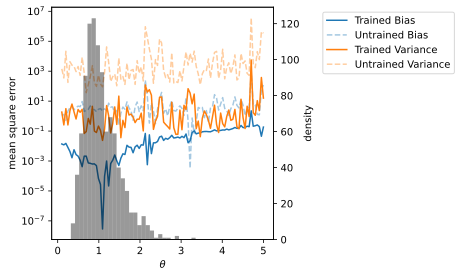

In [8]:
fig,ax = plt.subplots(figsize=(7,4))

# Calculate errors for both trained and untrained models
trained_errs = (trained_preds - truth)/truth
untrained_errs = (untrained_preds - truth)/truth

# Match theta values to the actual number of predictions we got
# Slice theta_tensor to match the length of predictions
n_preds = len(trained_preds)
theta_for_preds = theta_tensor[:n_preds]
theta_numpy = theta_for_preds.cpu().numpy()
unique_thetas = np.unique(theta_numpy)

# Calculate mean and std errors for trained model
trained_mean_errors = []
trained_std_errors = []
for theta_val in unique_thetas:
    mask = theta_numpy == theta_val
    theta_errors = trained_errs[mask]
    trained_mean_errors.append(np.mean(theta_errors)**2)
    trained_std_errors.append(np.var(theta_errors))

trained_mean_errors = np.array(trained_mean_errors)
trained_std_errors = np.array(trained_std_errors)

# Calculate mean and std errors for untrained model
untrained_mean_errors = []
untrained_std_errors = []
for theta_val in unique_thetas:
    mask = theta_numpy == theta_val
    theta_errors = untrained_errs[mask]
    untrained_mean_errors.append(np.mean(theta_errors)**2)
    untrained_std_errors.append(np.var(theta_errors))

untrained_mean_errors = np.array(untrained_mean_errors)
untrained_std_errors = np.array(untrained_std_errors)

# Plot histogram of training theta values on twin axis
axt = ax.twinx()
axt.hist(data['theta_values'].numpy(), 30, color="k", alpha=0.4)
axt.set_ylabel("density")

# Plot both trained and untrained model errors
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("mean square error")
ax.plot(unique_thetas, trained_mean_errors, 'C0-', label='Trained Bias')
ax.plot(unique_thetas, untrained_mean_errors, 'C0--', label='Untrained Bias', alpha=0.4)
ax.plot(unique_thetas, trained_std_errors, 'C1-', label='Trained Variance')
ax.semilogy(unique_thetas, untrained_std_errors, 'C1--', label='Untrained Variance', alpha=0.4)
ax.legend(bbox_to_anchor=(1.2, 1), loc='upper left')

plt.tight_layout()